# DS-7331 Lab Two -

### By Ahmad Salama, Titus Karuri, Eman Meraj, Sue Camara

In [67]:
# ---------------------------------------------------------
# Python Library Setup: Check and Install Required Dependencies
# ---------------------------------------------------------
import sys
import subprocess
import importlib.util as imp_util

# List of required libraries\packages for this notebook
required_packages = [
    "pandas",
    "missingno",
    "seaborn",
    "matplotlib",
    "math",
    "scikit-learn",
    "numpy"
]

for package in required_packages:
    # iterate over the required packages and if any is not installed, trigger a pip command
    # to install.
    if imp_util.find_spec(package) is None:
        print(f"Package '{package}' is not installed. Installing now...")
        # run the pip command
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.DEVNULL
        )
        print(f"Package '{package}' installed successfully.\n")
    else:
        print(f"Package '{package}' is already installed.\n")

# ---------------------------------------------------------
# Import required libraries\packages
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import os as os
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from sklearn import metrics as mt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import os
import math

Package 'pandas' is already installed.

Package 'missingno' is already installed.

Package 'seaborn' is already installed.

Package 'matplotlib' is already installed.

Package 'math' is already installed.

Package 'scikit-learn' is not installed. Installing now...
Package 'scikit-learn' installed successfully.

Package 'numpy' is already installed.



In [68]:
def print_section_header(title, char="=", width=80):
    print(char * width)
    print(title)
    print(char * width)

In [69]:
DATASET_NAME = "default_of_credit_card_clients.csv"
data_path = os.path.join(os.path.expanduser("~"), "Downloads", DATASET_NAME)
# load the dataset
df = pd.read_csv(data_path, header=1)

print_section_header(title="INITIAL DATA EXPLORATION")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

INITIAL DATA EXPLORATION
Dataset shape: (30000, 25)

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


As you can see above, the missing values matrix show a solid and uninterrupted block across all features. This indicate that there are no explicit missing values in the dataset. This observation is consistent with the dataset documentation, which states that the data does not contain any missing values.

In [70]:
# check data types
print_section_header("Data Types")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

Data Types
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

Basic Statistics:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Data Quality & Missing Values Analysis


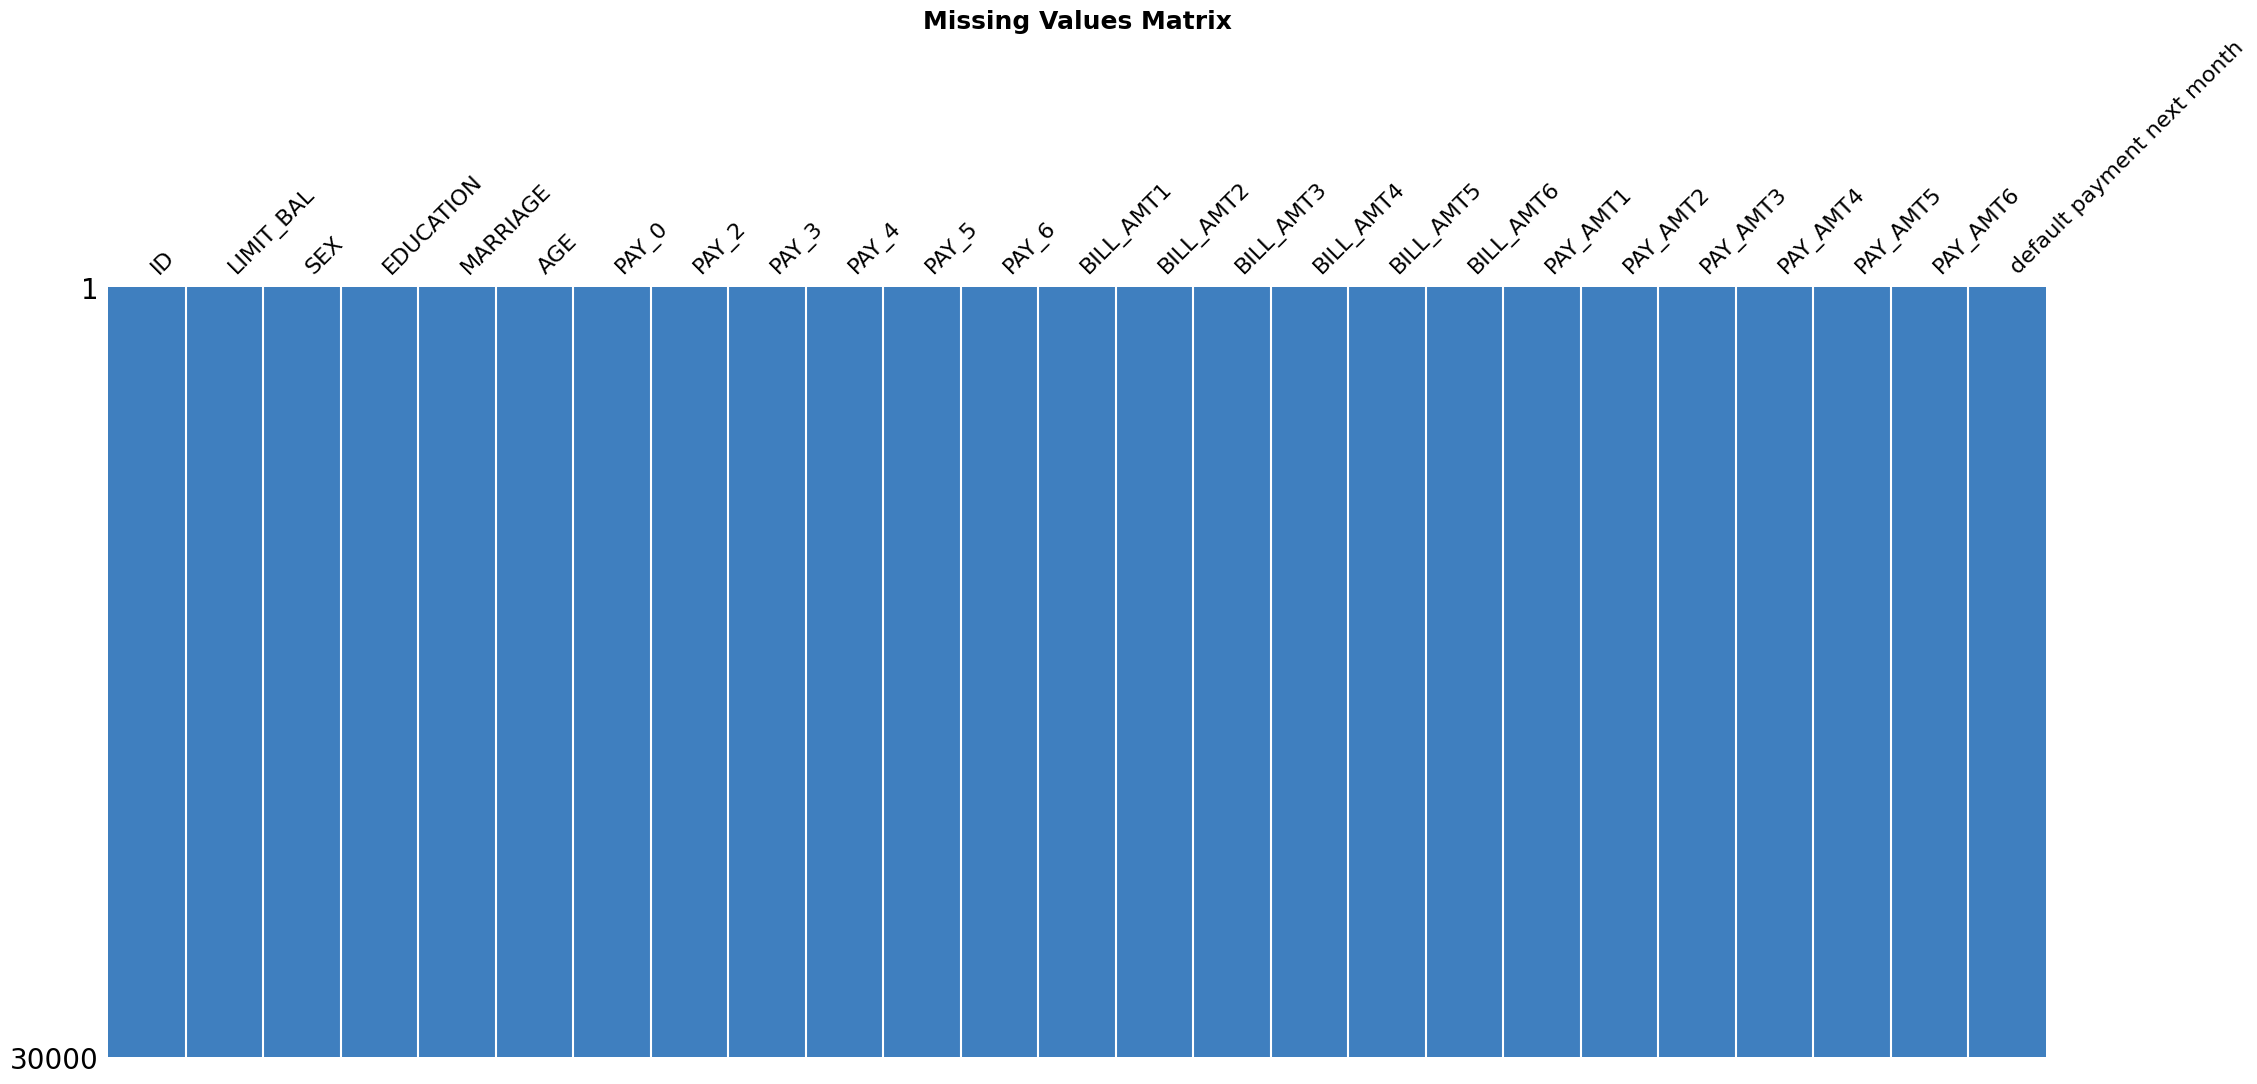

In [71]:
# Visualize dataset completeness using a missingno matrix plot
print_section_header("Data Quality & Missing Values Analysis")
msno.matrix(
    df,
    color=(0.25, 0.5, 0.75),
    sparkline=False
)
plt.title("Missing Values Matrix", fontsize=18, fontweight="bold")
plt.show()

As you can see above, the missing values matrix show a solid and uninterrupted block across all features. This indicate that there are no explicit missing values in the dataset. This observation is consistent with the dataset documentation, which states that the data does not contain any missing values.

In [72]:
# Verify that the target variable contains only binary decision values (0 = no default, 1 = default)
unique = df["default payment next month"].unique()
print(unique)

[1 0]


As part of the data quality analysis, we verified that the target variable (`default payment next month`) contains only binary decision values (0 and 1). This validation step ensures that the dataset is appropriate for binary classification models.

While our data doesn't have any missing values, during the exploratory analysis, we observed that some categorical features contain values that are undocumented. To better understand the extent and impact of these values, we visualize the distribution of the those variables using heatmaps. As we have observed in the previous labs, the count of the undocumented values are very small and we will handle them by merging into another appropriate categories to preserve data.

In [73]:
# Handle categorical variables
print_section_header("CATEGORICAL VARIABLE Analysis & Cleanup")

CATEGORICAL VARIABLE Analysis & Cleanup



SEX unique values: [2 1]
SEX
2    18112
1    11888
Name: count, dtype: int64


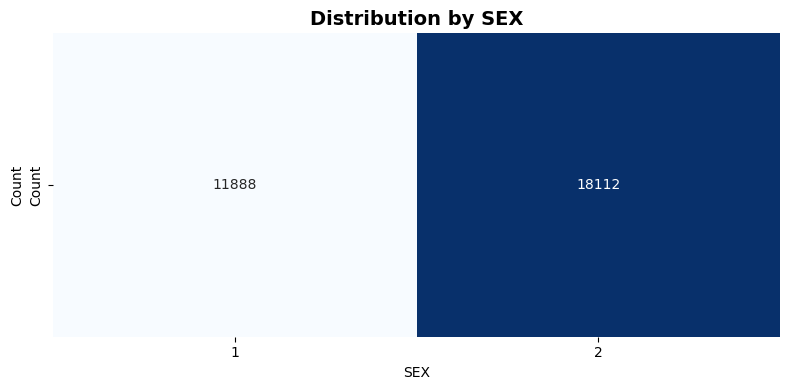


EDUCATION unique values: [2 1 3 5 4 6 0]
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


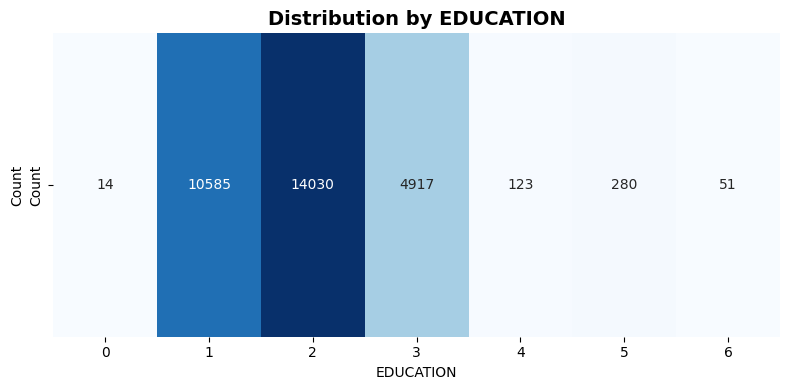


MARRIAGE unique values: [1 2 3 0]
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


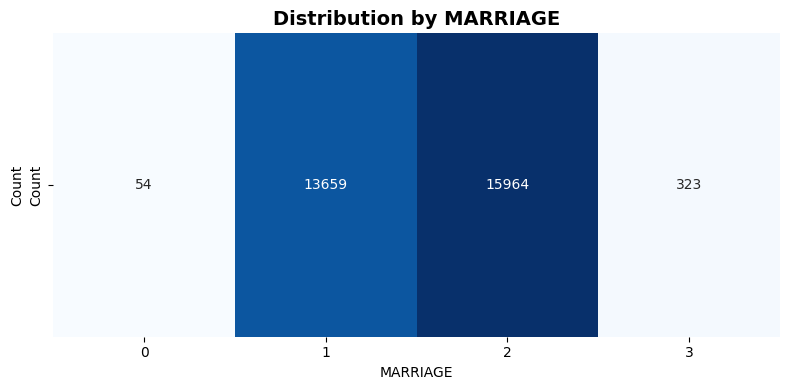


EDUCATION after cleaning (0,5,6 -> 4=Others):
EDUCATION
graduate_school    10585
high_school         4917
other                468
university         14030
Name: count, dtype: int64

MARRIAGE after cleaning (0 -> 3=Others):
MARRIAGE
divorced      323
married     13659
other          54
single      15964
Name: count, dtype: int64

SEX after encoding:
SEX
0    11888
1    18112
Name: count, dtype: int64


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,1,university,married,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,1,university,single,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,1,university,single,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,1,university,married,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,0,university,married,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [74]:

# Check unique values in categorical columns
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in categorical_cols:
    print(f"\n{col} unique values: {df[col].unique()}")
    print(df[col].value_counts())

    # Create heatmap for current column
    heatmap_data = (
        df[col]
        .value_counts()
        .sort_index()
        .to_frame(name="Count")
    )

    plt.figure(figsize=(8, 4))  # Create new figure for each column
    sns.heatmap(
        heatmap_data.T,  # Transpose for better visualization
        cmap="Blues",
        annot=True,
        fmt="d",
        cbar=False
    )

    plt.title(f"Distribution by {col}", fontsize=14, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# EDUCATION: 0, 5, 6 are undocumented categories
# 1=graduate school, 2=university, 3=high school, 4=others
# Merge 0, 5, 6 into 4 (others)
df['EDUCATION'] = df['EDUCATION'].map({1: 'graduate_school', 2: 'university',
                                        3: 'high_school', 0: 'other', 4: 'other',
                                        5: 'other', 6: 'other'})

print("\nEDUCATION after cleaning (0,5,6 -> 4=Others):")
print(df['EDUCATION'].value_counts().sort_index())

# MARRIAGE: 0 is undocumented
# 1=married, 2=single, 3=others
# Merge 0 into 3 (others)
df['MARRIAGE'] = df['MARRIAGE'].map({1: 'married', 2: 'single',
                                      3: 'divorced', 0: 'other'})
print("\nMARRIAGE after cleaning (0 -> 3=Others):")
print(df['MARRIAGE'].value_counts().sort_index())

# One-hot encode categorical variables
#df = pd.get_dummies(df, columns=['EDUCATION', 'MARRIAGE'], prefix=['edu', 'marriage'])

# Keep SEX as binary (1=male, 2=female) - convert to 0/1
df['SEX'] = df['SEX'] - 1  # Now 0=male, 1=female

print("\nSEX after encoding:")
print(df['SEX'].value_counts().sort_index())

df.head()

we checked each of the categorical variables to clean up any inconsistencies. For EDUCATION column, we have identified several undocumented codes (0, 5, and 6) lurking in the data. so we make a decission to group them with the existing "other" category so now we have four clear groups: graduate school, university, high school, and other. The MARRIAGE column had a similar issue with an undocumented 0 code, which we folded into the "other" category alongside divorced status so now we have three straightforward groups: married, single, and other. For SEX, we just simply it from 1/2 to 0/1 encoding to make it easier for modeling. With these cleanups done, the categorical variables are now much neater and ready for whatever analysis comes next.

In [75]:
# Drop the ID column - it's just a row identifier, not useful for prediction
df.drop('ID', axis=1, inplace=True)
print("Dropped 'ID' column (row identifier, not predictive).\n")

# Rename target column for convenience
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

# Rename PAY_0 to PAY_1 for consistency (it represents September payment status)
df.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)

Dropped 'ID' column (row identifier, not predictive).



We have performed essential data cleaning by dropping the non-predictive 'ID' column, renaming the target variable to 'DEFAULT' for consistency, and standardizing the payment status column names by changing 'PAY_0' to 'PAY_1' to create a logical sequence from PAY_1 (September) through PAY_6 (April). This resulting in a cleaner, dataset.

In [76]:
# Categorize all variables by their proper type
variable_types = {
        'LIMIT_BAL': 'continuous (float)',
        'SEX': 'binary categorical (int)',
        'EDUCATION': 'ordinal categorical (int)',
        'MARRIAGE': 'nominal categorical (int)',
        'AGE': 'continuous (int)',
        'PAY_1': 'ordinal (int) - repayment status Sept',
        'PAY_2': 'ordinal (int) - repayment status Aug',
        'PAY_3': 'ordinal (int) - repayment status Jul',
        'PAY_4': 'ordinal (int) - repayment status Jun',
        'PAY_5': 'ordinal (int) - repayment status May',
        'PAY_6': 'ordinal (int) - repayment status Apr',
        'BILL_AMT1': 'continuous (float) - bill statement Sept',
        'BILL_AMT2': 'continuous (float) - bill statement Aug',
        'BILL_AMT3': 'continuous (float) - bill statement Jul',
        'BILL_AMT4': 'continuous (float) - bill statement Jun',
        'BILL_AMT5': 'continuous (float) - bill statement May',
        'BILL_AMT6': 'continuous (float) - bill statement Apr',
        'PAY_AMT1': 'continuous (float) - payment Sept',
        'PAY_AMT2': 'continuous (float) - payment Aug',
        'PAY_AMT3': 'continuous (float) - payment Jul',
        'PAY_AMT4': 'continuous (float) - payment Jun',
        'PAY_AMT5': 'continuous (float) - payment May',
        'PAY_AMT6': 'continuous (float) - payment Apr',
        'DEFAULT': 'binary target (int)'
    }

print("="*80)
print("Data Types")
print("="*80)
for var, vtype in variable_types.items():
        print(f"  {var:15s} -> {vtype}")


Data Types
  LIMIT_BAL       -> continuous (float)
  SEX             -> binary categorical (int)
  EDUCATION       -> ordinal categorical (int)
  MARRIAGE        -> nominal categorical (int)
  AGE             -> continuous (int)
  PAY_1           -> ordinal (int) - repayment status Sept
  PAY_2           -> ordinal (int) - repayment status Aug
  PAY_3           -> ordinal (int) - repayment status Jul
  PAY_4           -> ordinal (int) - repayment status Jun
  PAY_5           -> ordinal (int) - repayment status May
  PAY_6           -> ordinal (int) - repayment status Apr
  BILL_AMT1       -> continuous (float) - bill statement Sept
  BILL_AMT2       -> continuous (float) - bill statement Aug
  BILL_AMT3       -> continuous (float) - bill statement Jul
  BILL_AMT4       -> continuous (float) - bill statement Jun
  BILL_AMT5       -> continuous (float) - bill statement May
  BILL_AMT6       -> continuous (float) - bill statement Apr
  PAY_AMT1        -> continuous (float) - payment Sept


DATA PREPROCESSING


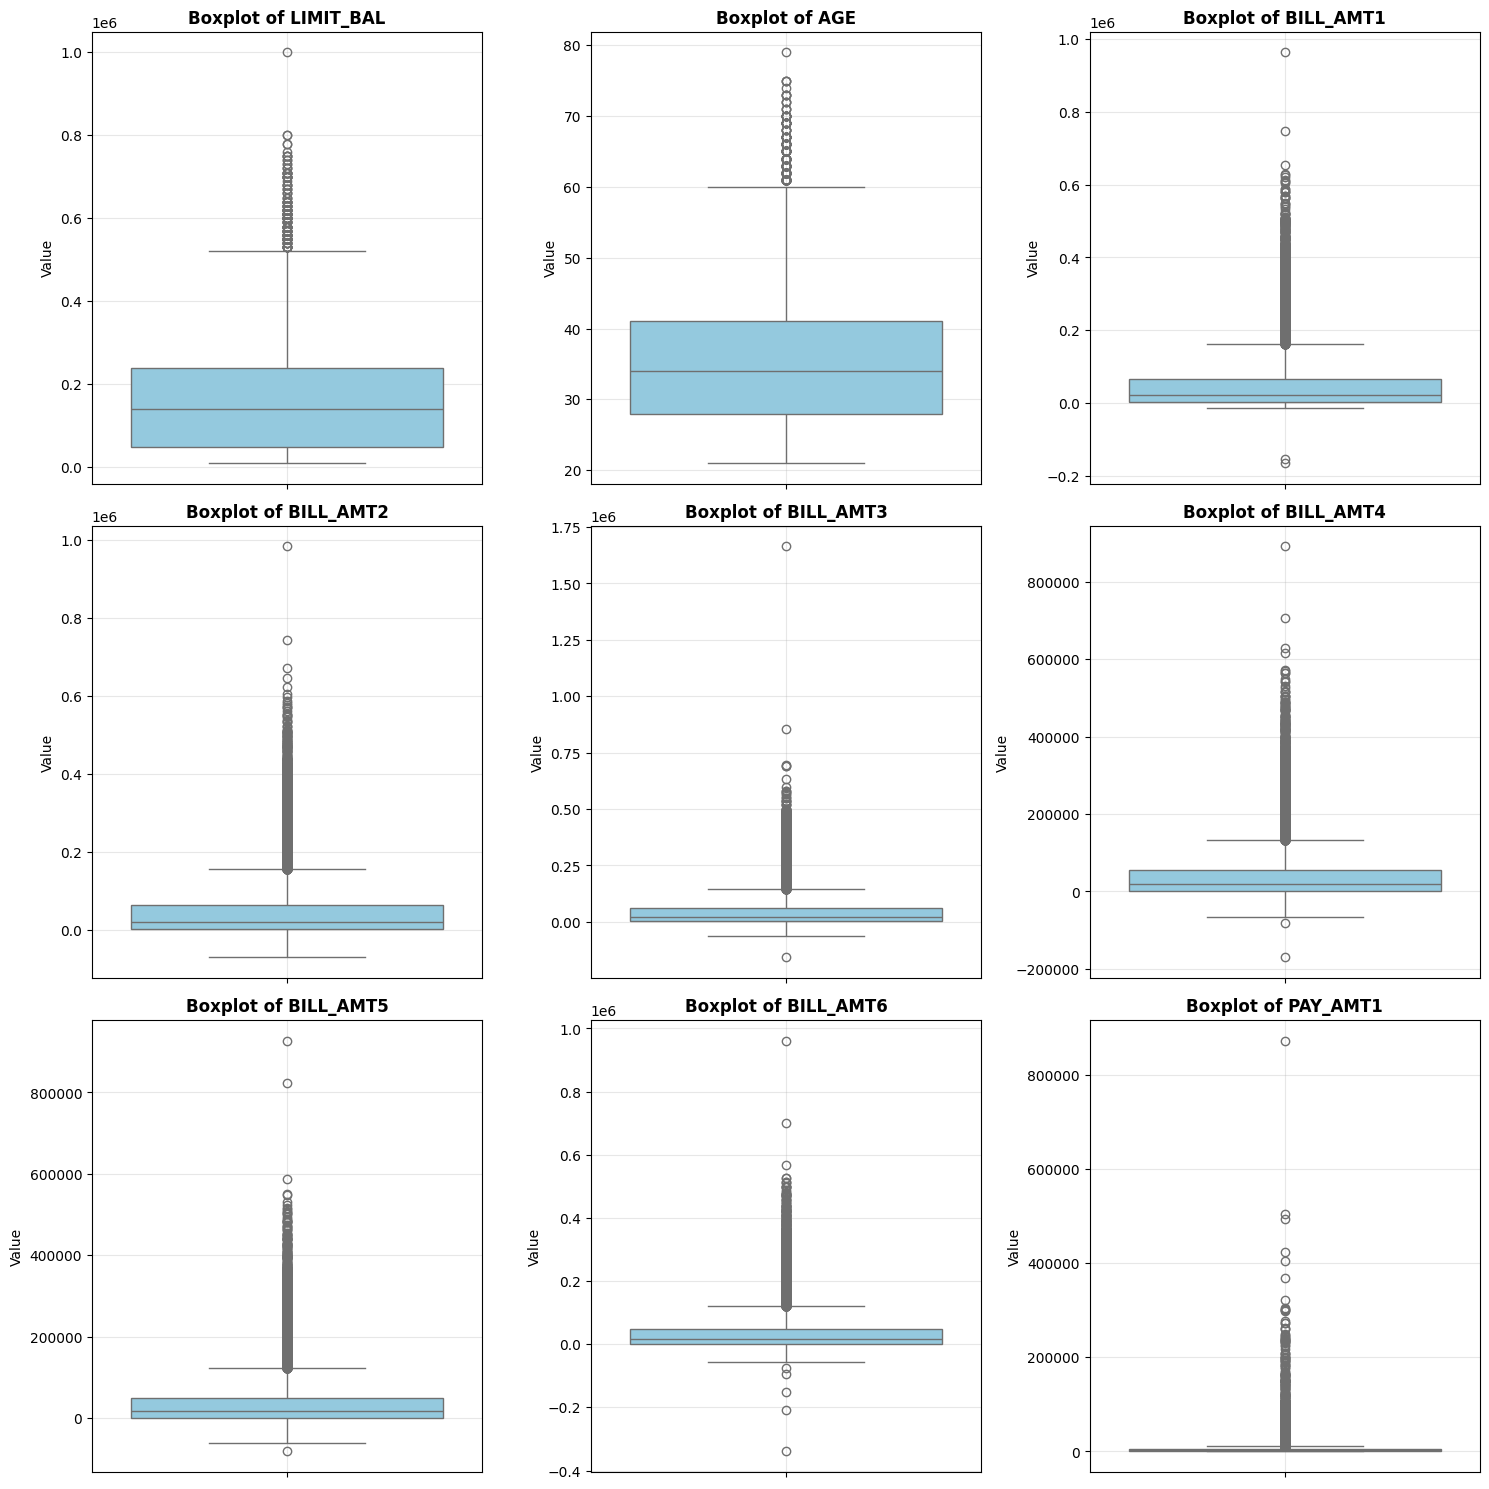

In [77]:
print_section_header("DATA PREPROCESSING")

# Check for outliers in numerical columns
numerical_cols = ['LIMIT_BAL', 'AGE'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

for i, col in enumerate(numerical_cols[:9]):  # Plot first 9 numerical columns
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

we will not remove outliers and rather handle outliers through scaling to preserve information

In [78]:
# Handle PAY_* columns - these are ordinal categorical variables
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("PAY values:")
for col in pay_columns:
    print(f"{col}: {df[col].unique()}")

PAY values:
PAY_1: [ 2 -1  0 -2  1  3  4  8  7  5  6]
PAY_2: [ 2  0 -1 -2  3  5  7  4  1  6  8]
PAY_3: [-1  0  2 -2  3  4  6  7  1  5  8]
PAY_4: [-1  0 -2  2  3  4  5  7  6  1  8]
PAY_5: [-2  0 -1  2  3  5  4  7  8  6]
PAY_6: [-2  2  0 -1  3  6  4  7  8  5]


### PAY values meaning:
* -2: No consumption
* -1: Paid in full
* 0: Revolving credit
* 1: Payment delay for 1 month
* 2: Payment delay for 2 months
* 3-8: Payment delay for 3+ months

In [79]:
print_section_header("FEATURE ENGINEERING")

FEATURE ENGINEERING


In [80]:
# Credit utilization ratio (average across 6 months)
# Ratio of bill amount to credit limit - measures how much of the available credit is used
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
for i, col in enumerate(bill_cols, 1):
    df[f'UTIL_RATIO_{i}'] = df[col] / df['LIMIT_BAL']

df['AVG_UTIL_RATIO'] = df[[f'UTIL_RATIO_{i}' for i in range(1,7)]].mean(axis=1)
df[[f'UTIL_RATIO_{i}' for i in range(1,7)]].head()

df['AVG_UTIL_RATIO'].head()

0    0.064200
1    0.023718
2    0.188246
3    0.771113
4    0.364463
Name: AVG_UTIL_RATIO, dtype: float64

The credit utilization ratio measures how much of the available credit line the
customer is using. High utilization is a classic predictor of financial distress,
as it indicates either increased spending or inability to pay down balances.

In [81]:
# Payment-to-Bill Ratio (how much of the bill was paid)
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
for i in range(1, 7):
    bill_col = f'BILL_AMT{i}'
    pay_col = f'PAY_AMT{i}'
    # if bill is 0 or negative, set ratio to 1 which means fully paid
    df[f'PAY_RATIO_{i}'] = np.where(
        df[bill_col] > 0,
        df[pay_col] / df[bill_col],
        1.0
    )
    df[f'PAY_RATIO_{i}'] = df[f'PAY_RATIO_{i}'].clip(0, 5)

df['AVG_PAY_RATIO'] = df[[f'PAY_RATIO_{i}' for i in range(1,7)]].mean(axis=1)

df[[f'PAY_RATIO_{i}' for i in range(1,7)]].head()

df['AVG_PAY_RATIO'].head()

0    0.537019
1    0.311916
2    0.115141
3    0.036396
4    1.002072
Name: AVG_PAY_RATIO, dtype: float64

The payment-to-bill ratio capture what portion of each month's statement balance was actually paid. For each month, we divided the payment amount by the corresponding bill amount - a ratio of 1 means the customer paid their entire bill, while values below 1 indicate partial payment. For cases where bills were zero or negative, we set the ratio to 1 (fully paid), and capped extreme values at 5 to limit outlier impact. We then created an average payment ratio across all six months to summarize each customer's typical payment behavior. This feature provides better context than raw payment amounts since it accounts for how much the customer actually owed.

In [82]:
# Average and Max Payment Delay
pay_status_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['AVG_PAY_STATUS'] = df[pay_status_cols].mean(axis=1)
df['MAX_PAY_STATUS'] = df[pay_status_cols].max(axis=1)

df['AVG_PAY_STATUS'].head()
df['MAX_PAY_STATUS'].head()

0    2
1    2
2    0
3    0
4    0
Name: MAX_PAY_STATUS, dtype: int64

Additionally, we created two summary features from the payment status columns: average payment delay and maximum payment delay across all six months. The average payment status gives a sense of a customer's typical repayment behavior, while the maximum captures their worst delinquency during the period. Together, these features provide both a central tendency and an extreme value perspective on payment punctuality.

In [83]:
# Number of times payment was delayed (PAY_X >= 1)
df['NUM_DELAYS'] = (df[pay_status_cols] >= 1).sum(axis=1)
df['NUM_DELAYS'].head()

0    2
1    2
2    0
3    0
4    0
Name: NUM_DELAYS, dtype: int64

To provider a measure of a customer's overall payment reliability, we created a feature counting how many times each customer had a delayed payment (payment status ≥ 1) across the six-month period.

In [84]:
# Number of times payment was severely delayed (PAY_X >= 3)
df['NUM_SEVERE_DELAYS'] = (df[pay_status_cols] >= 3).sum(axis=1)
print("NUM_SEVERE_DELAYS (count of months with payment delay >= 3)")
df['NUM_SEVERE_DELAYS'].head()

NUM_SEVERE_DELAYS (count of months with payment delay >= 3)


0    0
1    0
2    0
3    0
4    0
Name: NUM_SEVERE_DELAYS, dtype: int64

In order to identify customers with serious delinquency issues. We counted how many months each customer had a severe payment delay (status ≥ 3), highlighting their most problematic payment behavior during the period.

In [85]:
# Total bill amount and total payment amount over 6 months
df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)
df['TOTAL_PAY'] = df[pay_amt_cols].sum(axis=1)
df['TOTAL_BILL'].head()
df['TOTAL_PAY'].head()

0      689
1     5000
2    11018
3     8388
4    59049
Name: TOTAL_PAY, dtype: int64

In order to gain a big-picture view of each customer's overall credit usage and repayment activity, We calculated the total bill amount and total payment amount across all six months.

In [86]:
# Balance trend (is the balance increasing or decreasing?)
# Positive means balance is growing (bad sign)
df['BILL_TREND'] = df['BILL_AMT1'] - df['BILL_AMT6']
df['BILL_TREND'].head()

0     3913
1     -579
2    13690
3    17443
4   -10514
Name: BILL_TREND, dtype: int64

In order to better understand customer financial strain, we created a balance trend feature by subtracting the most recent bill amount (September) from the earliest (April) - a positive value indicates the customer's balance is growing over time, which could signal increasing financial strain.

In [87]:
# Age group (binned)
# AGE_GROUP (1=21-30, 2=31-40, 3=41-50, 4=51-60, 5=61+)
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 80], labels=[1, 2, 3, 4, 5]).astype(int)
df['AGE_GROUP'].head()


0    1
1    1
2    2
3    2
4    4
Name: AGE_GROUP, dtype: int64

For age, we grouped customers into age brackets (1=21-30, 2=31-40, 3=41-50, 4=51-60, 5=61+) to capture potential generational differences in payment behavior. This binning makes it easier to spot age-related patterns in the analysis.

In [88]:
print_section_header("MULTI-CLASS TARGET CREATION")

MULTI-CLASS TARGET CREATION


In [89]:
def classify_payment_behavior(row):
    """
    Classify payment behavior based on both severity and frequency of delays.
    Class 0: Good payers (max_status <= 0) - no delinquency
    Class 1: Minor delinquency (max_status in {1,2} OR max_status>=3 with <2 severe delays)
    Class 2: Major delinquency (max_status>=3 with 2+ severe delays)
    """
    max_status = row['MAX_PAY_STATUS']
    num_severe = row['NUM_SEVERE_DELAYS']

    if max_status <= 0:
        return 0  # Good payer
    elif max_status <= 2 or (max_status >= 3 and num_severe < 2):
        return 1  # Minor delinquency
    else:
        return 2  # Major delinquency

df['PAY_BEHAVIOR'] = df.apply(classify_payment_behavior, axis=1)

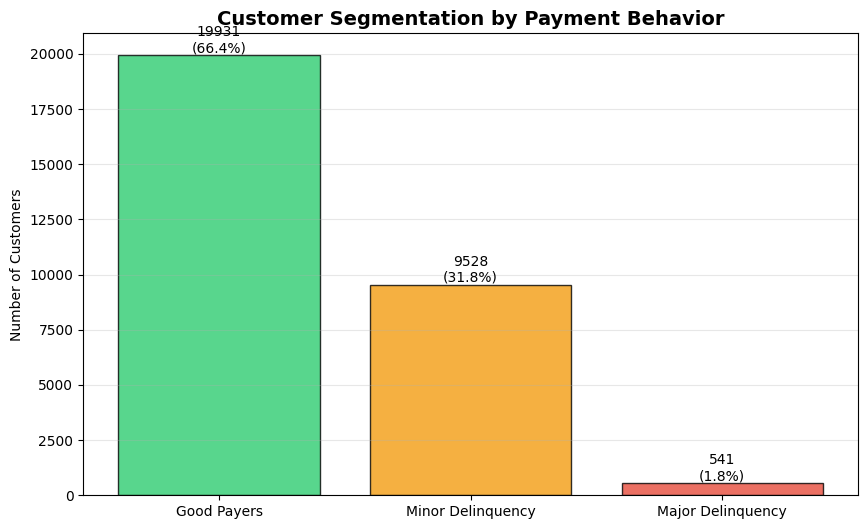

In [90]:
# Bar chart with counts
plt.figure(figsize=(10, 6))
behavior_counts = df['PAY_BEHAVIOR'].value_counts().sort_index()
bars = plt.bar(['Good Payers', 'Minor Delinquency', 'Major Delinquency'],
               behavior_counts.values,
               color=['#2ecc71', '#f39c12', '#e74c3c'],
               edgecolor='black', alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom')

plt.title('Customer Segmentation by Payment Behavior', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

The payment behavior classification feature combines both the severity and frequency of delays for a more nuanced customer profile. Good payers (Class 0) are those with no delinquency across all six months. Minor delinquency (Class 1) captures customers who either had only small delays (1-2 months) or had a serious delay but it was an isolated incident (less than two months with severe delinquency). Major delinquency (Class 2) identifies customers with a pattern of serious payment issues (those with severe delays in two or more months). The bar chart that most of the users are categorized as good payers and the majority of the remaining are minor delinquency and smmall precentage is major delinquency.

In [91]:
# clean up the dataset and drop original categorical colum and replace with encoded versions.
cols_to_drop = ['SEX', 'EDUCATION', 'MARRIAGE']
df.drop(cols_to_drop, axis=1, inplace=True)
print(f"\nDropped original categorical columns: {cols_to_drop}")

# Also drop individual utilization ratios and payment ratios (keep averages to reduce dimensionality)
util_ratio_cols = [f'UTIL_RATIO_{i}' for i in range(1,7)]
pay_ratio_cols = [f'PAY_RATIO_{i}' for i in range(1,7)]
df.drop(util_ratio_cols + pay_ratio_cols, axis=1, inplace=True)



Dropped original categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE']


In [92]:
print(f"\nFirst 5 rows:")
df.head()


First 5 rows:


,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,AVG_PAY_RATIO,AVG_PAY_STATUS,MAX_PAY_STATUS,NUM_DELAYS,NUM_SEVERE_DELAYS,TOTAL_BILL,TOTAL_PAY,BILL_TREND,AGE_GROUP,PAY_BEHAVIOR
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,0.537019,-0.333333,2,2,0,7704,689,3913,1,1
1,120000,26,-1,2,0,0,0,2,2682,1725,...,0.311916,0.500000,2,2,0,17077,5000,-579,1,1
2,90000,34,0,0,0,0,0,0,29239,14027,...,0.115141,0.000000,0,0,0,101653,11018,13690,2,0
3,50000,37,0,0,0,0,0,0,46990,48233,...,0.036396,0.000000,0,0,0,231334,8388,17443,2,0
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,1.002072,-0.333333,0,0,0,109339,59049,-10514,4,0


In [93]:
# check data types
print_section_header("Data Types")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

Data Types
LIMIT_BAL              int64
AGE                    int64
PAY_1                  int64
PAY_2                  int64
PAY_3                  int64
PAY_4                  int64
PAY_5                  int64
PAY_6                  int64
BILL_AMT1              int64
BILL_AMT2              int64
BILL_AMT3              int64
BILL_AMT4              int64
BILL_AMT5              int64
BILL_AMT6              int64
PAY_AMT1               int64
PAY_AMT2               int64
PAY_AMT3               int64
PAY_AMT4               int64
PAY_AMT5               int64
PAY_AMT6               int64
DEFAULT                int64
AVG_UTIL_RATIO       float64
AVG_PAY_RATIO        float64
AVG_PAY_STATUS       float64
MAX_PAY_STATUS         int64
NUM_DELAYS             int64
NUM_SEVERE_DELAYS      int64
TOTAL_BILL             int64
TOTAL_PAY              int64
BILL_TREND             int64
AGE_GROUP              int64
PAY_BEHAVIOR           int64
dtype: object

Basic Statistics:


,LIMIT_BAL,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,AVG_PAY_RATIO,AVG_PAY_STATUS,MAX_PAY_STATUS,NUM_DELAYS,NUM_SEVERE_DELAYS,TOTAL_BILL,TOTAL_PAY,BILL_TREND,AGE_GROUP,PAY_BEHAVIOR
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,...,0.519780,-0.182439,0.438733,0.834200,0.078000,2.698617e+05,3.165139e+04,12351.570500,1.993400,0.353667
std,129747.661567,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,...,0.577278,0.982176,1.345154,1.554303,0.464604,3.795643e+05,6.082768e+04,43922.421534,0.956619,0.514453
min,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,...,0.000000,-2.000000,-2.000000,0.000000,0.000000,-3.362590e+05,0.000000e+00,-428791.000000,1.000000,0.000000
25%,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,...,0.046673,-0.833333,0.000000,0.000000,0.000000,2.868800e+04,6.679750e+03,-2963.000000,1.000000,0.000000
50%,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,...,0.197466,0.000000,0.000000,0.000000,0.000000,1.263110e+05,1.438300e+04,923.000000,2.000000,0.000000
75%,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,...,0.947718,0.000000,2.000000,1.000000,0.000000,3.426265e+05,3.350350e+04,19793.750000,3.000000,1.000000
max,1000000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,...,3.500000,6.000000,8.000000,6.000000,6.000000,5.263883e+06,3.764066e+06,708323.000000,5.000000,2.000000


In [94]:
print_section_header("CORRELATION ANALYSIS FOR MULTICOLLINEARITY")

# Check highly correlated feature pairs
feature_cols = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR']]
corr_matrix = df[feature_cols].corr()

# Find pairs with |correlation| > 0.8
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print("Highly correlated feature pairs (|r| > 0.8):")
for c1, c2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {c1} <-> {c2}: r = {r:.4f}")

# The BILL_AMT columns are highly correlated with each other
# We'll keep them but note this for the report
# TOTAL_BILL is a summary, so we could consider dropping individual BILL_AMTs


CORRELATION ANALYSIS FOR MULTICOLLINEARITY
Highly correlated feature pairs (|r| > 0.8):
  BILL_AMT4 <-> TOTAL_BILL: r = 0.9645
  BILL_AMT3 <-> TOTAL_BILL: r = 0.9620
  BILL_AMT2 <-> TOTAL_BILL: r = 0.9612
  AGE <-> AGE_GROUP: r = 0.9564
  BILL_AMT5 <-> TOTAL_BILL: r = 0.9517
  BILL_AMT1 <-> BILL_AMT2: r = 0.9515
  BILL_AMT5 <-> BILL_AMT6: r = 0.9462
  BILL_AMT4 <-> BILL_AMT5: r = 0.9401
  BILL_AMT1 <-> TOTAL_BILL: r = 0.9401
  BILL_AMT6 <-> TOTAL_BILL: r = 0.9287
  BILL_AMT2 <-> BILL_AMT3: r = 0.9283
  BILL_AMT3 <-> BILL_AMT4: r = 0.9240
  BILL_AMT4 <-> BILL_AMT6: r = 0.9009
  BILL_AMT2 <-> BILL_AMT4: r = 0.8925
  BILL_AMT1 <-> BILL_AMT3: r = 0.8923
  PAY_4 <-> AVG_PAY_STATUS: r = 0.8910
  BILL_AMT3 <-> BILL_AMT5: r = 0.8839
  PAY_3 <-> AVG_PAY_STATUS: r = 0.8781
  PAY_5 <-> AVG_PAY_STATUS: r = 0.8775
  BILL_AMT1 <-> BILL_AMT4: r = 0.8603
  BILL_AMT2 <-> BILL_AMT5: r = 0.8598
  BILL_AMT3 <-> BILL_AMT6: r = 0.8533
  PAY_2 <-> AVG_PAY_STATUS: r = 0.8504
  BILL_AMT2 <-> BILL_AMT6: r = 0.8

<function matplotlib.pyplot.show(close=None, block=None)>

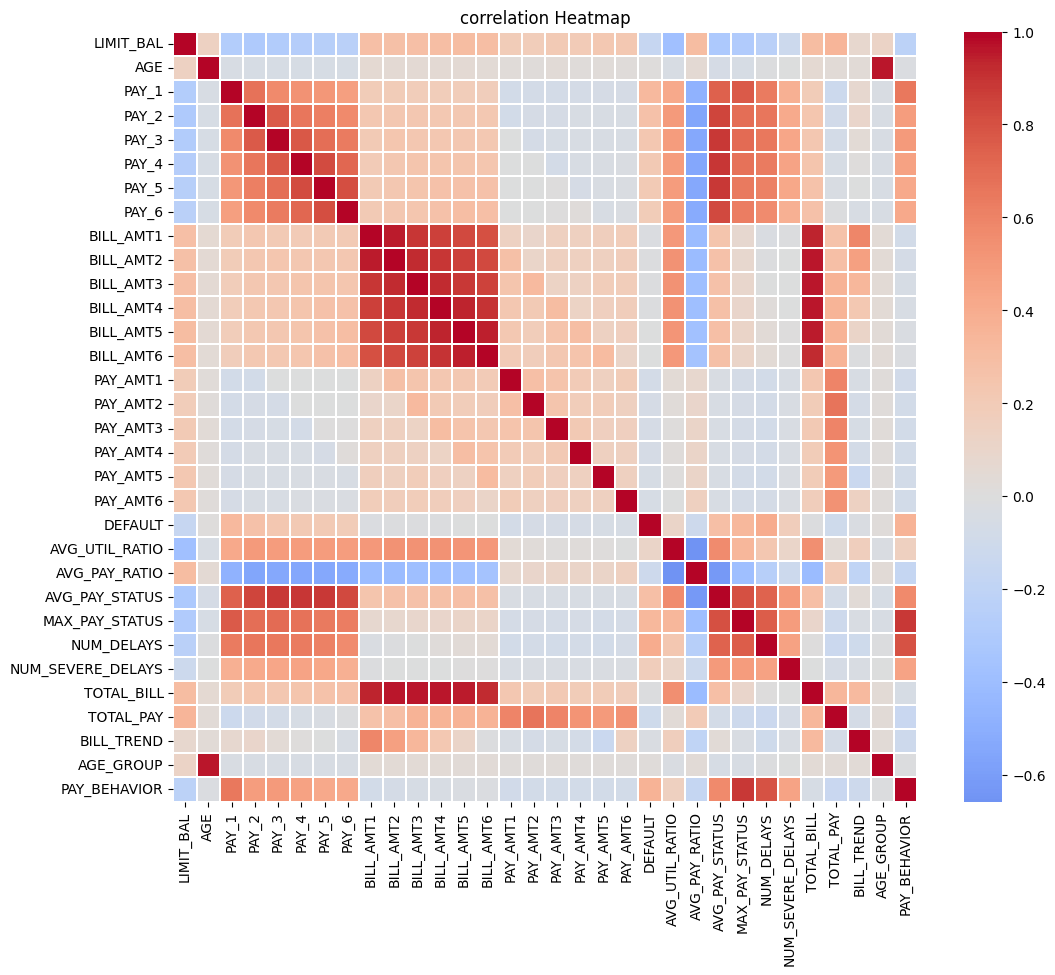

In [95]:
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()

plt.figure(figsize= (12,10))
sns.heatmap(corr, cmap = "coolwarm", center =0, linewidth= 0.2)
plt.title("correlation Heatmap")
plt.show

Our multicollinearity check shows that monthly bill amounts are highly correlated with each other and with our TOTAL_BILL summary (0.83 to 0.96) - if someone had a high bill in April, they likely had high bills all year. Also, AGE and AGE_GROUP at 0.96 which is not a surprise since we created one from the other.

In [96]:
print_section_header("FINAL DATASET PREPARATION")

FINAL DATASET PREPARATION


let's examine each of the continuous features and use a Box and scatter plots to visually identify potential outliers and evaluate the distribution of the values across the dataset.

Generating box plots for 32 numerical features...


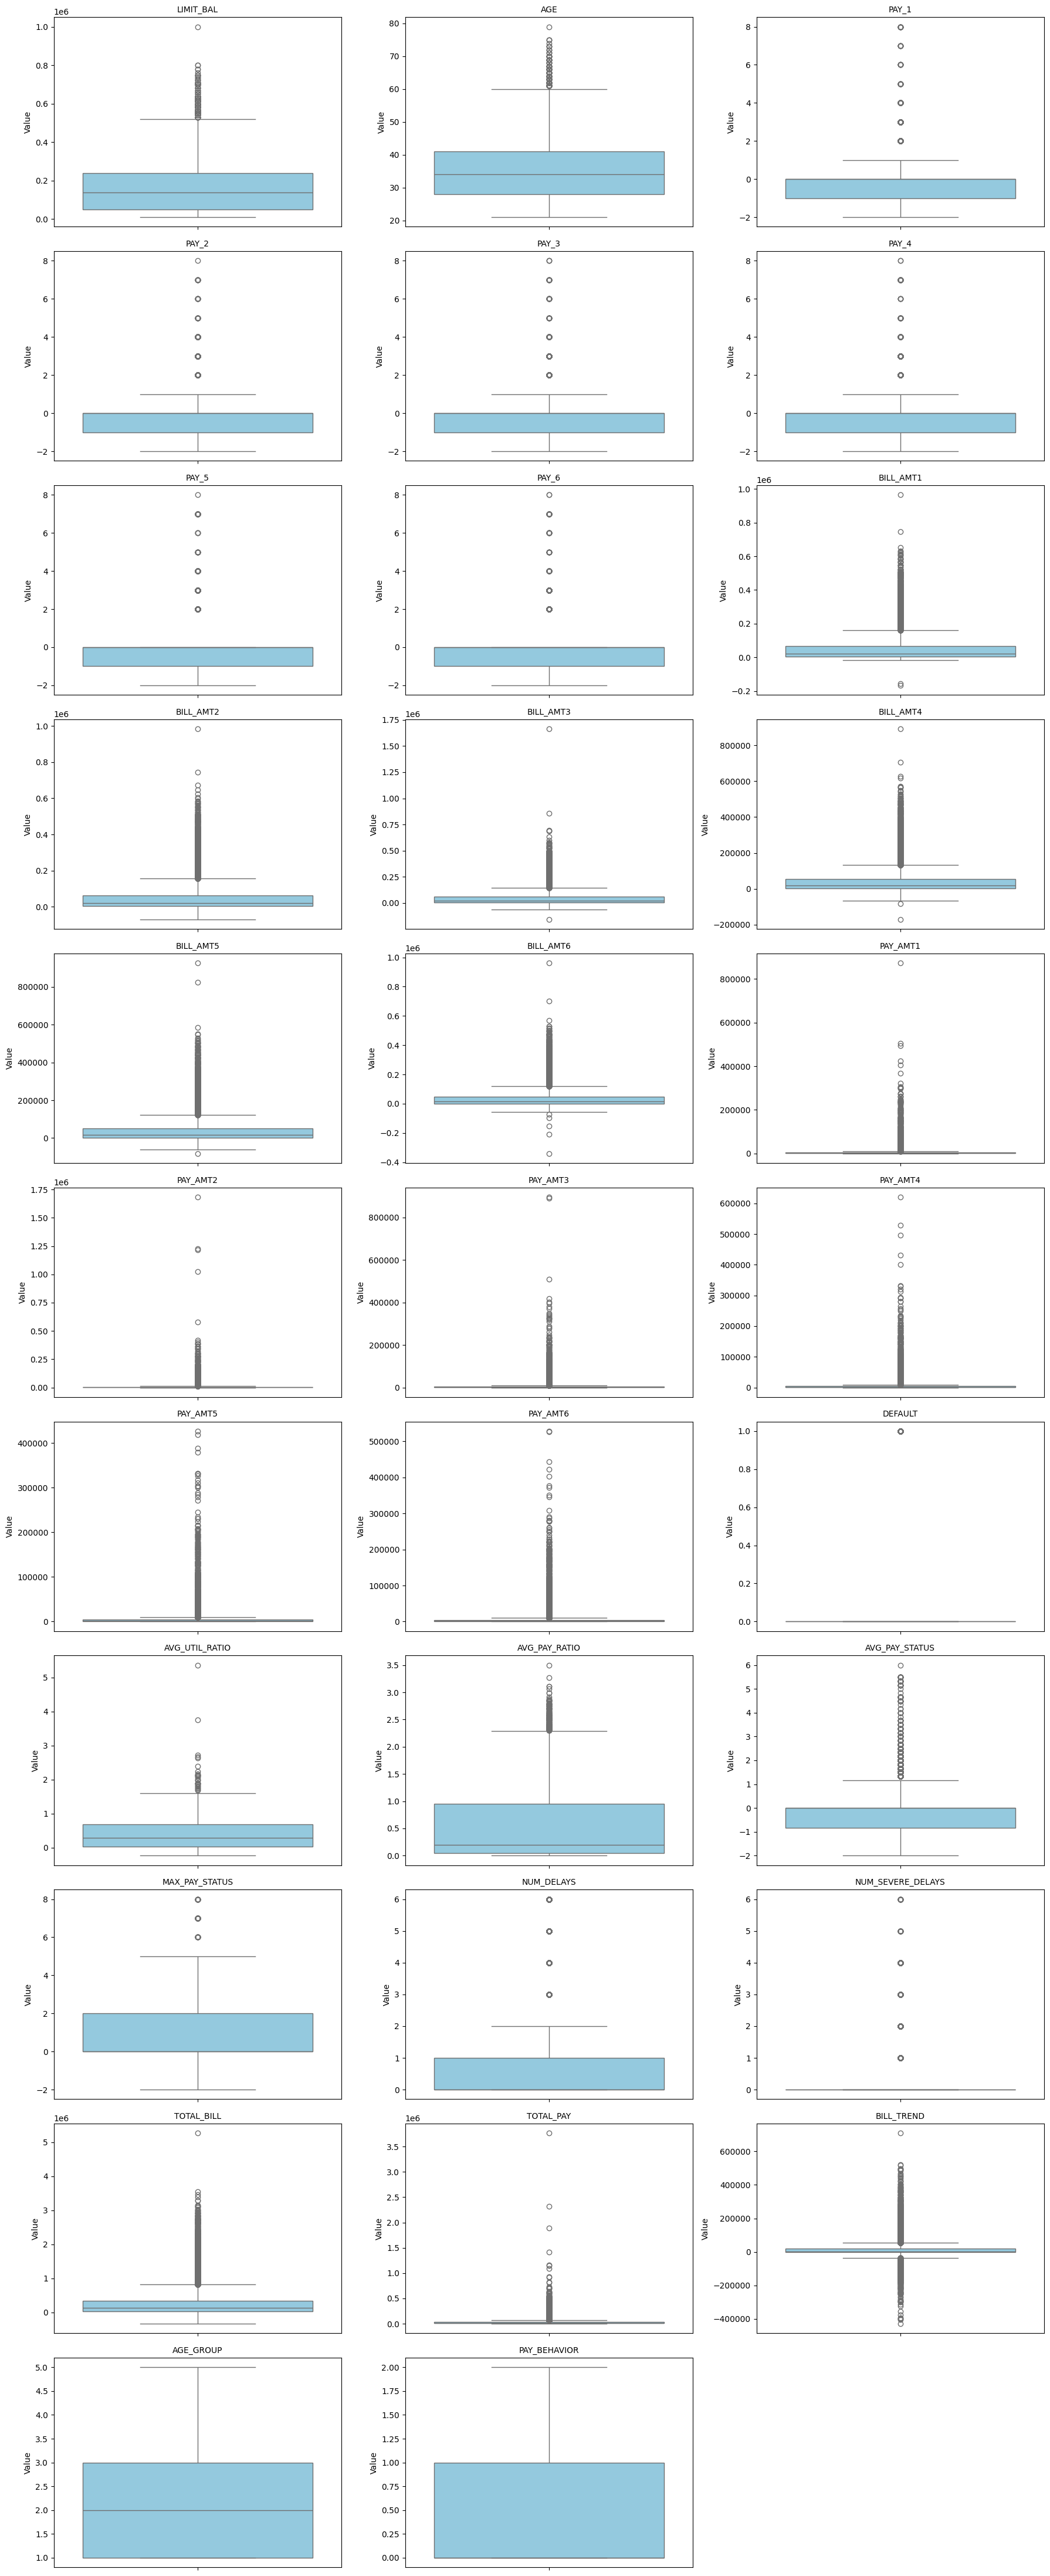

In [97]:
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Generating box plots for {len(numerical_vars)} numerical features...")

# Number of plots per row
plots_per_row = 3
# Calculate the required number of rows for the subplot grid
rows = math.ceil(len(numerical_vars) / plots_per_row)
# Create a figure with a dynamically scaled size
plt.figure(figsize=(plots_per_row * 6, rows * 4))

# Generate a boxplot for each numerical variable
for i, col in enumerate(numerical_vars, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel('Value')

# Adjust the padding between and around subplots
plt.tight_layout()
plt.show()

Generating scatter plots for 32 numerical features...


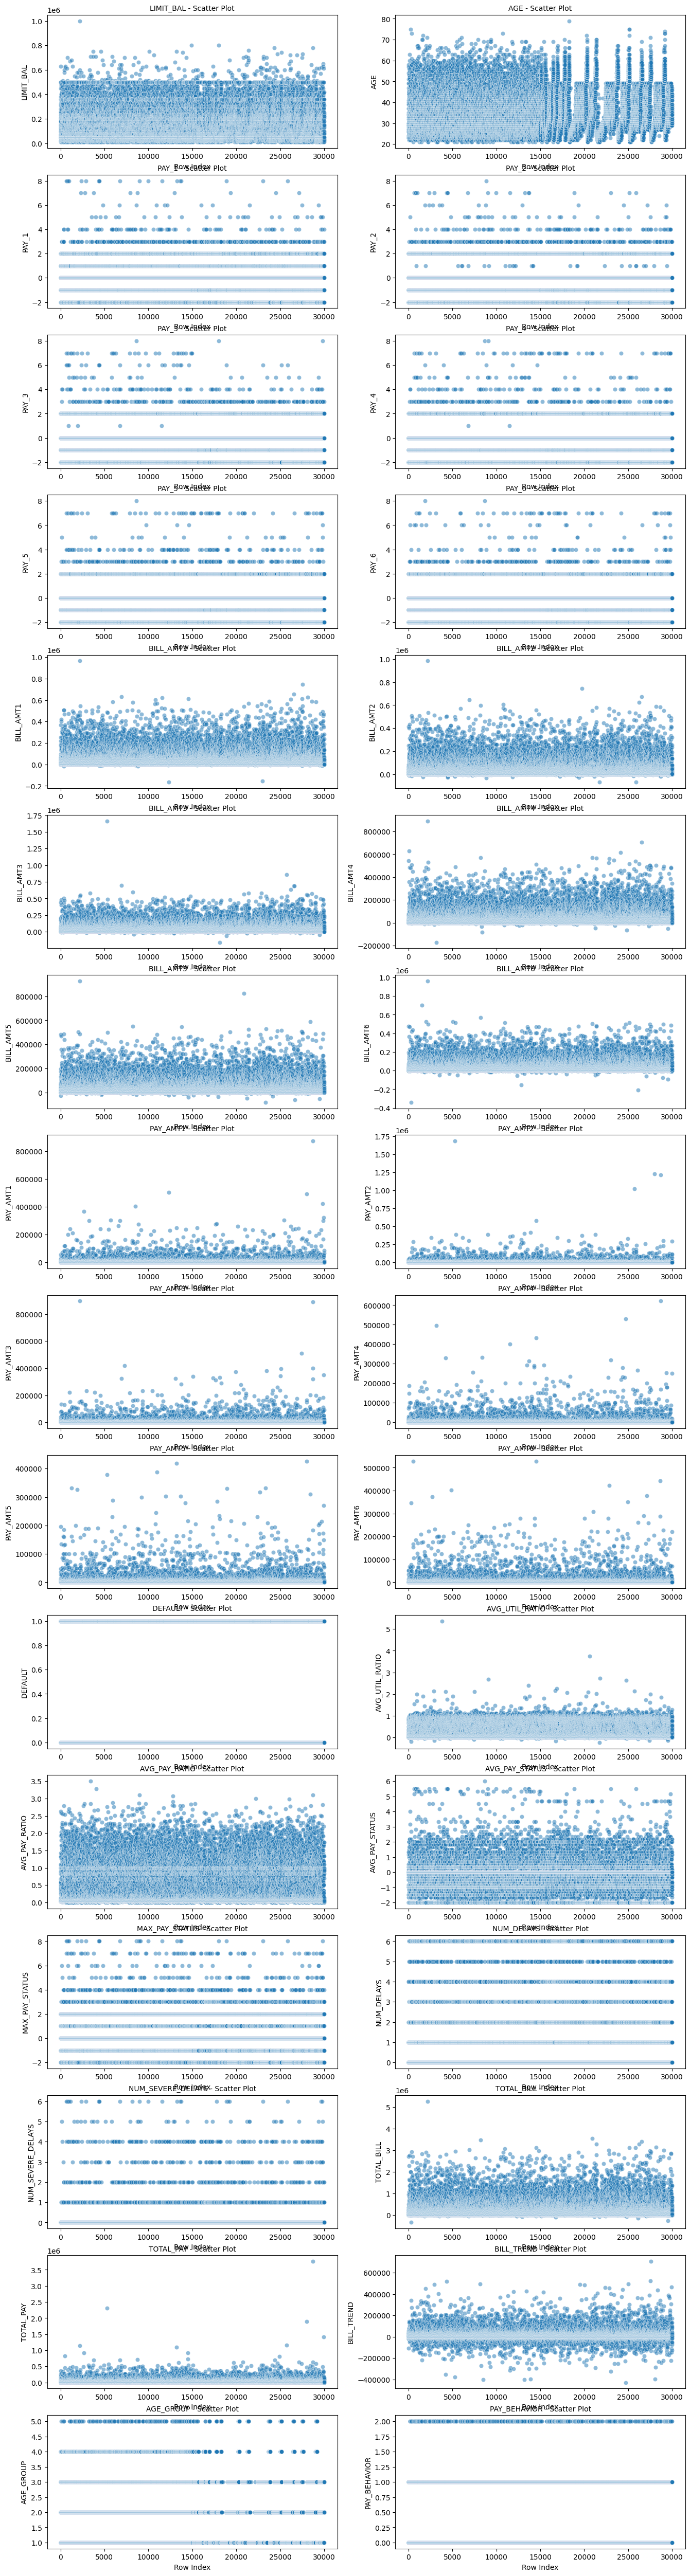

In [98]:
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Generating scatter plots for {len(numerical_vars)} numerical features...")

# Number of plots per row
plots_per_row = 2
# Calculate the required number of rows for the subplot grid
rows = math.ceil(len(numerical_vars) / plots_per_row)
# Create a figure with a dynamically scaled size
plt.figure(figsize=(plots_per_row * 8, rows * 4))

# Generate a scatter plot for each numerical variable
for i, col in enumerate(numerical_vars, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.scatterplot(data=df, x=df.index, y=col, alpha=0.5)
    plt.title(f"{col} - Scatter Plot", fontsize=10)
    plt.xlabel("Row Index")
    plt.ylabel(col)

In [99]:
# Features for Task 1 (Default Prediction)
# Remove PAY_BEHAVIOR (it's the Task 2 target, and would leak info)
task1_features = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR']]
task1_target = 'DEFAULT'

# Features for Task 2 (Payment Behavior Classification)
# Remove DEFAULT (it's the Task 1 target)
# Also remove PAY_1 through PAY_6 since they directly define PAY_BEHAVIOR (data leakage!)
task2_features = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR',
                                                       'PAY_1', 'PAY_2', 'PAY_3',
                                                       'PAY_4', 'PAY_5', 'PAY_6',
                                                       'AVG_PAY_STATUS', 'MAX_PAY_STATUS',
                                                       'NUM_DELAYS', 'NUM_SEVERE_DELAYS']]
task2_target = 'PAY_BEHAVIOR'
print(f"Task 1 Features ({len(task1_features)}): {task1_features}")
print(f"Task 1 Target: {task1_target}")
print(f"\nTask 2 Features ({len(task2_features)}): {task2_features}")
print(f"Task 2 Target: {task2_target}")


Task 1 Features (30): ['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'AVG_PAY_STATUS', 'MAX_PAY_STATUS', 'NUM_DELAYS', 'NUM_SEVERE_DELAYS', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND', 'AGE_GROUP']
Task 1 Target: DEFAULT

Task 2 Features (20): ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND', 'AGE_GROUP']
Task 2 Target: PAY_BEHAVIOR


In [100]:
print_section_header("SCALING")

# Check the range of continuous features
continuous_features = ['LIMIT_BAL', 'AGE'] + \
                     [f'BILL_AMT{i}' for i in range(1,7)] + \
                     [f'PAY_AMT{i}' for i in range(1,7)] + \
                     ['AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND']

print("Feature ranges before scaling:")
for feat in continuous_features:
    if feat in df.columns:
        print(f"  {feat:20s}: min={df[feat].min():12.2f}, max={df[feat].max():12.2f}, mean={df[feat].mean():12.2f}, std={df[feat].std():12.2f}")

print("\nNote: StandardScaler will be applied during modeling to normalize features.")

SCALING
Feature ranges before scaling:
  LIMIT_BAL           : min=    10000.00, max=  1000000.00, mean=   167484.32, std=   129747.66
  AGE                 : min=       21.00, max=       79.00, mean=       35.49, std=        9.22
  BILL_AMT1           : min=  -165580.00, max=   964511.00, mean=    51223.33, std=    73635.86
  BILL_AMT2           : min=   -69777.00, max=   983931.00, mean=    49179.08, std=    71173.77
  BILL_AMT3           : min=  -157264.00, max=  1664089.00, mean=    47013.15, std=    69349.39
  BILL_AMT4           : min=  -170000.00, max=   891586.00, mean=    43262.95, std=    64332.86
  BILL_AMT5           : min=   -81334.00, max=   927171.00, mean=    40311.40, std=    60797.16
  BILL_AMT6           : min=  -339603.00, max=   961664.00, mean=    38871.76, std=    59554.11
  PAY_AMT1            : min=        0.00, max=   873552.00, mean=     5663.58, std=    16563.28
  PAY_AMT2            : min=        0.00, max=  1684259.00, mean=     5921.16, std=    23040.87
 

## Model Classifications

In [101]:
#DEFAULT
x_default =df[task1_features]
y_default = df[task1_target]

x_train_default, x_test_default, y_train_default, y_test_default = train_test_split(

    x_default,y_default,test_size=0.2, random_state=42, stratify=y_default

)


In [102]:

#PAY_BEHAVIOR
x_pay =df[task2_features]
y_pay = df[task2_target]

x_train_pay, x_test_pay, y_train_pay, y_test_pay = train_test_split(

    x_pay,y_pay,test_size=0.2, random_state=42, stratify=y_pay

)

# Logistic Regression

In [103]:
log_model = Pipeline(
    [("scaler", StandardScaler()),
     ("clf", LogisticRegression(max_iter=2000, random_state=42))]
)

# KNN

In [104]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

# Random Forrest

In [105]:
random_forrest_model = RandomForestClassifier(random_state=42)

# Tuning Parameters

In [106]:
##Logistic Regression tuning DEFAULT

for c in [0.01, 0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=c, max_iter=2000, random_state=42))
    ])
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    score = f1_score(y_test_default,y_pred,average="macro")
    print("C =", c, "F1 =", score)

C = 0.01 F1 = 0.6416324171324134
C = 0.1 F1 = 0.6451548451548452
C = 1 F1 = 0.6442370347389067
C = 10 F1 = 0.6442370347389067


In [107]:
##Logistic Regression tuning PAY_BEHAVIOR

for c in [0.01, 0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=c, max_iter=2000, random_state=42))
    ])
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    score = f1_score(y_test_pay,y_pred,average="macro")
    print("C =", c, "F1 =", score)

C = 0.01 F1 = 0.36595936874940205
C = 0.1 F1 = 0.38366004649565527
C = 1 F1 = 0.4182603383002393
C = 10 F1 = 0.49705080034659116


In [108]:
##KNN tuning DEFAULT
for k in [3, 5, 7, 9]:
    model = Pipeline([
        ("scaler", StandardScaler()),
         ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    score = f1_score(y_test_default,y_pred,average="macro")
    print("k =", k, "F1 =", score)

k = 3 F1 = 0.6524714684301244
k = 5 F1 = 0.6625078118749272
k = 7 F1 = 0.6669487806407122
k = 9 F1 = 0.6697261882935245


In [109]:
##KNN tuning PAY_BEHAVIOR
for k in [3, 5, 7, 9]:
    model = Pipeline([
        ("scaler", StandardScaler()),
         ("clf", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    score = f1_score(y_test_pay,y_pred,average="macro")
    print("k =", k, "F1 =", score)

k = 3 F1 = 0.48558901622076606
k = 5 F1 = 0.49167985567790956
k = 7 F1 = 0.48041705935428886
k = 9 F1 = 0.48066798547760475


In [110]:
##Random Forrest tuning DEFAULT
for depth in [None, 5, 10, 20]:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    score = f1_score(y_test_default,y_pred,average="macro")
    print("max_depth =", depth, "F1 =", score)


max_depth = None F1 = 0.6761568158941929
max_depth = 5 F1 = 0.6780158739933597
max_depth = 10 F1 = 0.6750025120578778
max_depth = 20 F1 = 0.6784642344227129


In [111]:
##Random Forrest tuning PAY_BEHAVIOR
for depth in [None, 5, 10, 20]:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    score = f1_score(y_test_pay,y_pred,average="macro")
    print("max_depth =", depth, "F1 =", score)

max_depth = None F1 = 0.7802706988261132
max_depth = 5 F1 = 0.68901240983922
max_depth = 10 F1 = 0.7637050296546076
max_depth = 20 F1 = 0.7757908906225562


## Evaluate Models

In [112]:
#DEFAULT
tuned_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=0.01, max_iter=2000, random_state=42))
])

tuned_knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=7))
])

tuned_random_forrest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

models = {
    "Logistic Regression": tuned_log_model,
    "KNN": tuned_knn_model,
    "Random Forest": tuned_random_forrest_model
}

for name, model in models.items():
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_default, y_pred))
    print("Precision:", precision_score(y_test_default, y_pred, average="macro"))
    print("Recall:", recall_score(y_test_default, y_pred, average="macro"))
    print("F1:", f1_score(y_test_default, y_pred, average="macro"))
    print(classification_report(y_test_default, y_pred))


Logistic Regression
Accuracy: 0.8076666666666666
Precision: 0.7360150156302997
Recall: 0.6213013848736775
F1: 0.6416324171324134
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.65      0.29      0.40      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.62      0.64      6000
weighted avg       0.79      0.81      0.78      6000


KNN
Accuracy: 0.8016666666666666
Precision: 0.709272791171333
Recall: 0.6487453538267826
F1: 0.6669487806407122
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      4673
           1       0.58      0.37      0.46      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.65      0.67      6000
weighted avg       0.78      0.80      0.79      6000


Random Forest
Accuracy: 0.8155
Precision: 0.7427551366338552
Recall: 0.6551980295016779
F1: 0.67846423

In [113]:

#PAY_BEHAVIOR
tuned_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=10, max_iter=2000, random_state=42))
])

tuned_knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=3))
])

tuned_random_forrest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

models = {
    "Logistic Regression": tuned_log_model,
    "KNN": tuned_knn_model,
    "Random Forest": tuned_random_forrest_model
}

for name, model in models.items():
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_pay, y_pred))
    print("Precision:", precision_score(y_test_pay, y_pred, average="macro"))
    print("Recall:", recall_score(y_test_pay, y_pred, average="macro"))
    print("F1:", f1_score(y_test_pay, y_pred, average="macro"))
    print(classification_report(y_test_pay, y_pred))




Logistic Regression
Accuracy: 0.6938333333333333
Precision: 0.7353422991798556
Recall: 0.46089548655353907
F1: 0.49705080034659116
              precision    recall  f1-score   support

           0       0.71      0.93      0.81      3986
           1       0.57      0.22      0.31      1906
           2       0.93      0.23      0.37       108

    accuracy                           0.69      6000
   macro avg       0.74      0.46      0.50      6000
weighted avg       0.67      0.69      0.64      6000


KNN
Accuracy: 0.6805
Precision: 0.6236710938793619
Recall: 0.45445829442989316
F1: 0.48558901622076606
              precision    recall  f1-score   support

           0       0.73      0.85      0.78      3986
           1       0.51      0.36      0.42      1906
           2       0.63      0.16      0.25       108

    accuracy                           0.68      6000
   macro avg       0.62      0.45      0.49      6000
weighted avg       0.66      0.68      0.66      6000


R

For DEFAULT, the tuned Logistic Regression model used C = 0.01, the tuned KNN model used k = 7, and the tuned Random Forest model used max_depth = 20. Among these, Random Forest performed best with an accuracy of 0.8143 and a macro F1 score of 0.6768. KNN was second-best with a macro F1 of 0.6594, followed by Logistic Regression at 0.6450.

For PAY_BEHAVIOR, the tuned Logistic Regression model used C = 10, the tuned KNN model used k = 3, and the tuned Random Forest model used max_depth = 20. Random Forest again performed best, with an accuracy of 0.8815 and a macro F1 score of 0.7884. This was substantially better than KNN, which achieved a macro F1 of 0.4261, and Logistic Regression, which achieved 0.3692.

Overall, Random Forest was the strongest model for both prediction tasks. The results suggest that nonlinear relationships in the data were important, especially for predicting PAY_BEHAVIOR, where the tree-based ensemble model greatly outperformed the linear and distance-based methods.

 Logistic Regression provided a useful baseline because it is simple, fast, and easy to interpret, but it was limited in capturing more complex nonlinear relationships. KNN was able to model local neighborhood structure and slightly outperformed Logistic Regression for both tasks, but its performance was still weaker than Random Forest and it depends heavily on feature scaling and the choice of k. Random Forest had the strongest advantage because it can model nonlinear effects and feature interactions, which appear to be important in this dataset, especially for PAY_BEHAVIOR.

## Feature/Attribute Importance

In [114]:
#DEFAULT important features

tuned_random_forrest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

models = {"Random Forest": tuned_random_forrest_model}

for name, model in models.items():
    model.fit(x_train_default, y_train_default)
    y_pred = model.predict(x_test_default)


In [115]:

importances = tuned_random_forrest_model.feature_importances_
feature_names = x_default.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df.head(10))



           Feature  Importance
2            PAY_1    0.077105
22  AVG_PAY_STATUS    0.050990
20  AVG_UTIL_RATIO    0.048800
27       TOTAL_PAY    0.044490
28      BILL_TREND    0.043644
1              AGE    0.043416
21   AVG_PAY_RATIO    0.042127
26      TOTAL_BILL    0.040476
23  MAX_PAY_STATUS    0.039878
8        BILL_AMT1    0.039453


In [116]:
#PAY_BEHAVIOR important features

tuned_random_forrest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

models = {"Random Forest": tuned_random_forrest_model}

for name, model in models.items():
    model.fit(x_train_pay, y_train_pay)
    y_pred = model.predict(x_test_pay)

In [117]:

importances = tuned_random_forrest_model.feature_importances_
feature_names = x_pay.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df.head(10))



          Feature  Importance
8        PAY_AMT1    0.119315
9        PAY_AMT2    0.116603
10       PAY_AMT3    0.073049
15  AVG_PAY_RATIO    0.066617
2       BILL_AMT1    0.058267
11       PAY_AMT4    0.058185
18     BILL_TREND    0.056864
12       PAY_AMT5    0.054727
3       BILL_AMT2    0.046890
4       BILL_AMT3    0.046038


Feature/Attribute importance was evaluated using the feature_importances_ attribute from the tuned Random Forest models. For DEFAULT, the most important attributes were PAY_1, AVG_PAY_STATUS, AVG_UTIL_RATIO, TOTAL_PAY, BILL_TREND, AGE, AVG_PAY_RATIO, TOTAL_BILL, MAX_PAY_STATUS, and BILL_AMT1. These results suggest that default prediction depends heavily on recent repayment status, historical delinquency patterns, credit utilization, and the relationship between balances and payments. This is reasonable because customers with recent missed or delayed payments and heavier credit usage are more likely to default.

For PAY_BEHAVIOR, the most important attributes were PAY_AMT1, PAY_AMT2, PAY_AMT3, AVG_PAY_RATIO, BILL_AMT1, PAY_AMT4, BILL_TREND, PAY_AMT5, BILL_AMT2, and BILL_AMT3. This indicates that payment behavior is driven primarily by the actual amounts paid and billed across recent months, along with the overall payment-to-balance relationship. These attributes are likely more important because they directly reflect how consistently and aggressively a customer pays down their balances over time.

Overall, the feature importance results align with intuition: DEFAULT is more closely associated with delinquency and utilization measures, while PAY_BEHAVIOR is more closely associated with payment and billing patterns.

GRID SEARCH VISUALIZATION


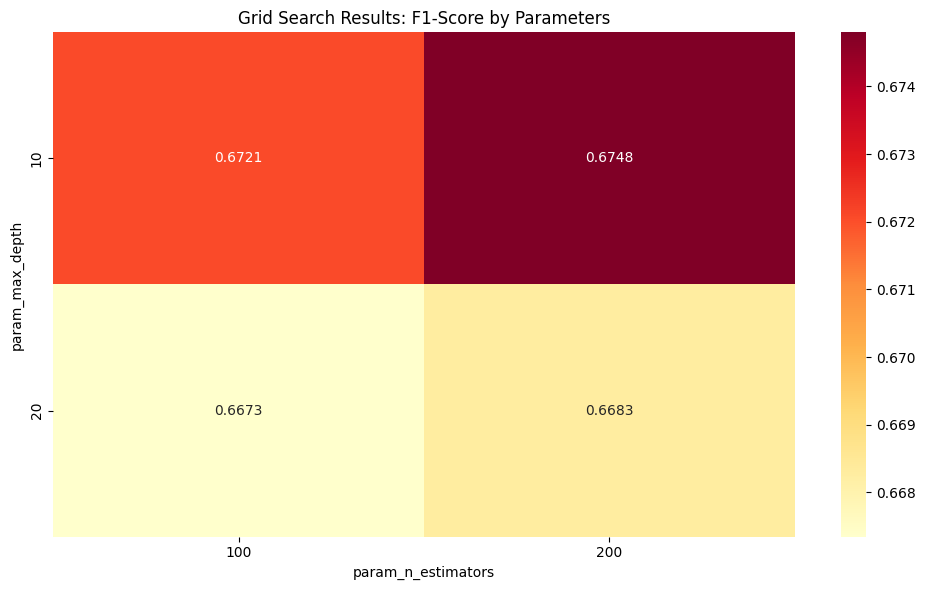


Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-score: 0.6763


In [119]:
print_section_header("GRID SEARCH VISUALIZATION")

from sklearn.model_selection import GridSearchCV
import seaborn as sns

# Simple grid search on key parameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Use sample for faster execution
sample_size = min(5000, len(x_train_default))
X_sample = x_train_default.sample(n=sample_size, random_state=42)
y_sample = y_train_default.loc[X_sample.index]

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(X_sample, y_sample)

# Visualize results
results = pd.DataFrame(grid_search.cv_results_)

# Create heatmap for max_depth vs n_estimators
plt.figure(figsize=(10, 6))
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd')
plt.title('Grid Search Results: F1-Score by Parameters')
plt.tight_layout()
plt.show()

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best F1-score: {grid_search.best_score_:.4f}")